# Note on the implementation

Most of the initial implementation was provided as course material in BERN02. My work focused on running and understanding the implementation, writing comments, interpreting the different components of the neural network, experimenting with the provided code, and making modifications where appropriate.\
\
## My contribution

- Studied and interpreted the provided neural network implementation
- Ran and evaluated the model on bird and dog image data
- Analysed the forward and backward propagation steps
- Experimented with model parameters and training behaviour
- Modified parts of the provided implementation
- Documented and commented on the code

In [ ]:
#If the cv2 module is not found, run that:
#!pip install opencv-python

In [ ]:
import sys,os
import numpy as np                     #main package for scientific computing with Python.
import pandas as pd                    #main data handling package
from matplotlib import image           #plot graphs in Python.
import matplotlib.pyplot as plt        #lazy plotting
import cv2                             #image opening

# Building and training a neural network


First some background:

There are six components to artificial neurons. From left (input) to right (output). Only considering numerical values these are:

1. Input nodes. Each input node is a real number
2. Connections with weight. Each connection that departs from the input node has a weight, which is also a real number.
3. Calculate a weighted sum
4. Feed this sum into a transfer or activation function. normally this is a treshold function. 
Which however is not smooth, so alternatively a continous (sigmoid) function such as the logistic function is an alternative
5. output node of this chain
6. A perceptron is sometimes added to this, often this is called a bias, Which is an input node with a fixed value

With the percepton the treshold is easier defined, meaning that the transfer function can be switching at zero. (sometimes called ReLU Rectifying Linear Unit)

# Data Loading
Load the data with bird and dog images

In [ ]:
import sys
if "google.colab" in sys.modules:
    path_to_files = os.sep.join([os.getcwd(), "Bern02", "Labs", "Neural_Networks", "train"])
    !git clone https://github.com/luchem/Bern02.git --depth=1
else:
    path_to_files = os.sep.join([os.getcwd(), "train"])

Cloning into 'Bern02'...
remote: Enumerating objects: 2456, done.
remote: Counting objects: 100% (2456/2456), done.
remote: Compressing objects: 100% (2455/2455), done.
remote: Total 2456 (delta 0), reused 2447 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2456/2456), 17.74 MiB | 15.59 MiB/s, done.


In [ ]:
# Create two empty lists to store the the images and the labels (0 if bird, 1 if dog)
data=[]
labels=[]
image_size=15
# Load the data into the notebook from the folder on the computer
for filename in os.listdir(os.sep.join([path_to_files,'bird'])):
    labels.append(0)
    data.append(cv2.resize(image.imread(os.sep.join([path_to_files,'bird',filename])),dsize=(image_size,image_size)))
for filename in os.listdir(os.sep.join([path_to_files,'dog'])):
    labels.append(1)
    data.append(cv2.resize(image.imread(os.sep.join([path_to_files,'dog',filename])),dsize=(image_size,image_size)))
data=np.array(data)
labels=np.array(labels)

Split into a training and testing dataset, by using index

In [ ]:
np.random.seed(0)
idx=np.random.permutation(len(labels))
idx_train=idx[0:2000]
idx_test=idx[2001:2401]
train_x=data[idx_train]
test_x=data[idx_test]
train_y=labels[idx_train].reshape(1,-1)
test_y=labels[idx_test].reshape(1,-1)

# Data Inspection

the shape of the image is:
(15, 15, 3)


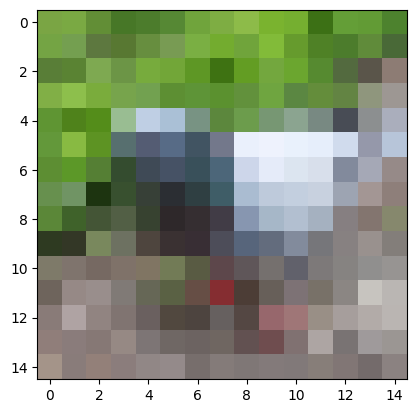

In [ ]:
print('the shape of the image is:')
print(train_x[0].shape)
plt.imshow(train_x[4])

# Data shaping

To avoid divergence, normalize the intensity of each pixels and flatten it. The flattening is a simplification to not have to deal with the dimensions.

In [ ]:
# fallening the matrix by using a single dimension layer
train_x_flatten=train_x.reshape(train_x.shape[0],-1).T
test_x_flatten=test_x.reshape(test_x.shape[0],-1).T
# all values must be normalized(between 0 and 1)
train_x_flatten=train_x_flatten/255
test_x_flatten=test_x_flatten/255

# Neuronal net building
Start with building the neural net, initialize with weights and biases for each layer.

In [ ]:
def initialize_parameters(n_x, n_h, n_y):
    """
    n_x -- size of input layer;
    n_h -- size of hidden layer;
    n_y -- size of output layer
    Returns:
    parameters -- python dictionary containing your parameters:
    """
    W1 = np.random.randn(n_h, n_x) * 0.01 #W1 -- weight matrix of shape (n_h, n_x)
    b1 = np.zeros((n_h, 1))               #b1 -- bias vector of shape (n_h, 1)
    W2 = np.random.randn(n_y, n_h) * 0.01 #W2 -- weight matrix of shape (n_y, n_h)
    b2 = np.zeros((n_y, 1))               #b2 -- bias vector of shape (n_y, 1)
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    return parameters

Code the forward propagation through  (from the input to the output (left to right)

In [ ]:
def linear_forward(Input_Matrix, Weights, bias):
    """
    function to calculate the combination of Input, weights and bias
    forward propagation.
    Returns: Output_Matrix, (Input_Matrix, Weights, bias)
    """
    Output_Matrix = np.dot(Weights, Input_Matrix) + bias
    cache = (Input_Matrix, Weights, bias)
    return Output_Matrix, cache
def relu(Z):# forward activation
    return np.maximum(np.zeros(Z.shape),Z),Z
def sigmoid(Z): # forward activation 
    return 1/(1+np.exp(-Z)),Z
def linear_activation_forward(Input_Matrix, Weights, bias, activation_method):
    """
    Input_Matrix: size of previous layer
    Weights: numpy array of shape (size of current layer, size of previous layer)
    bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer "sigmoid" or "relu"
    Returns: Output_Matrix, (linear_cache, activation_cache)
    """
    if activation_method == "sigmoid":
        Z, linear_cache = linear_forward(Input_Matrix, Weights, bias)
        Output_Matrix, activation_cache = sigmoid(Z)
    elif activation_method == "relu":
        Z, linear_cache = linear_forward(Input_Matrix, Weights, bias)
        Output_Matrix, activation_cache = relu(Z)
    cache = (linear_cache, activation_cache)
    return Output_Matrix, cache

In [ ]:
def compute_cost(Calculated_classiciation,True_classification):
    """Calculate the cost=error of the current prediction"""
    m = True_classification.shape[1] #get size of vector
    a=np.multiply(np.log(Calculated_classiciation),True_classification)
    b=np.multiply(np.log(1-Calculated_classiciation),1-True_classification)
    cost =  (-1./m)*np.sum(a+b)
    cost = np.squeeze(cost)# To make sure your cost's shape is what's expected
    return cost

In the forward propagate stage, the data flows through the network to get the outputs. Then the loss function calculated the total error. Backpropagation the calculates the gradient of the loss function with respect to each weight and bias.
This gradient helps us to predict how we should adjust the parameter of the weights more efficiently

In [ ]:
def linear_backward(dCost, cache):
    """linear backward step
    dCost=cost gradient, cache -- from forward step (Input_Matrix, Weights, bias)

    Returns:
    dInput -- Gradient of the cost with respect to the activation
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    Input_Matrix, Weights, bias = cache
    m = Input_Matrix.shape[1]
    dWeights = (1./m)*np.dot(dCost, Input_Matrix.T)
    dbias = (1./m)*np.sum(dCost, axis=1, keepdims=True)
    dActivation = np.dot(Weights.T, dCost)
    return dActivation, dWeights, dbias

def relu_backward(dA, activation_cache):
    return np.multiply(dA,np.heaviside(activation_cache,0))
def sigmoid_backward(dA,activation_cache):
    return np.multiply(dA,np.multiply(sigmoid(activation_cache)[0],np.ones(activation_cache.shape)-sigmoid(activation_cache)[0]))

def linear_activation_backward(dCost, cache, activation_method):
    """Complete backward step:
    dCost -- cost gradient;
    cache -- (linear_cache, activation_cache);
    activation -- the method as string: "sigmoid" or "relu"

    Returns:
    dActivation, dCost in respect to activation
    dWeights, dCost in respect to weights
    dbias, dCost in respect to bias
    """
    linear_cache, activation_cache = cache

    if activation_method == "relu":
        dZ = relu_backward(dCost, activation_cache)
        dActivation, dWeights, dbias = linear_backward(dZ, linear_cache)
    elif activation_method == "sigmoid":
        dZ = sigmoid_backward(dCost, activation_cache)
        dActivation, dWeights, dbias = linear_backward(dZ, linear_cache)
    return dActivation, dWeights, dbias


In [ ]:
def update_parameters(parameters, gradients, learning_rate):
    """ Update parameters using gradient descent
    Arguments: parameters (dict), gradients (dict), learning_rate = L_model_backward
    Returns:
    updated parameters (dict)
    """
    L = int(len(parameters.keys())/2) # number of layers in the neural network
    for l in range(L):
        parameters["W%i"%(l+1)] -= learning_rate * gradients["dW%i"%(l+1)]
        parameters["b%i"%(l+1)] -= learning_rate * gradients["db%i"%(l+1)]
    return parameters

In [ ]:
def predictions(X,Y,parameters):
    # Get W1, b1, W2 and b2 from the dictionary parameters.
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    A1, cache1 = linear_activation_forward(X, W1, b1, activation_method='relu')
    A2, cache2 = linear_activation_forward(A1, W2, b2, activation_method='sigmoid')
    Z=np.floor(A2+0.5).astype(int)
    return np.sum((Z==Y).astype(int))/len(Y.T)

In [ ]:
### CONSTANTS DEFINING THE MODEL ####
n_x = image_size*image_size*3#3072     # num_px * num_px * 3
n_h = 128  #nr nodes
n_y = 1 #layer thickness
layers_dims = (n_x, n_h, n_y)

In [ ]:
def two_layer_model(X, Y, layers_dims, learning_rate = 0.05, num_iterations = 500, print_cost_every=None):
    """LINEAR->RELU->LINEAR->SIGMOID.
    X Image_input of shape (n_x, number of examples)
    Y Vector with true "labels" (containing 0 if bird, 1 if dog)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost_every -- printing iteration
    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """
    grads = {}
    costs = []                              # to keep track of the cost
    m = X.shape[1]                           # number of examples
    accuracy_train=[]
    accuracy_test=[]
    (n_x, n_h, n_y) = layers_dims
    # Initialize parameters dictionary, by calling one of the functions previously implemented
    parameters = initialize_parameters(n_x, n_h, n_y)

    for i in range(0, num_iterations):# Loop (gradient descent)

        # Forward propagation: LINEAR -> RELU -> LINEAR -> SIGMOID.
        A1, cache1 = linear_activation_forward(X, parameters["W1"], parameters["b1"], activation_method='relu')
        A2, cache2 = linear_activation_forward(A1, parameters["W2"], parameters["b2"], activation_method='sigmoid')
        # Compute cost
        cost = compute_cost(A2, Y)
        # Initializing backward propagation
        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        # Backward propagation. (calculate gradients)
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation_method="sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation_method="relu")
        # Set grads['dWl'] to dW1, grads['db1'] to db1, grads['dW2'] to dW2, grads['db2'] to db2
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2

        # Update parameters.
        learning_rate*=0.999
        parameters = update_parameters(parameters, grads, learning_rate)
        # Print the cost every 20 training example
        if print_cost_every is None:
            continue
        else:
            if i % print_cost_every == 0:
                accur=predictions(train_x_flatten,train_y,parameters)
                accur2=predictions(test_x_flatten,test_y,parameters)
                accuracy_train.append(accur)
                accuracy_test.append(accur2)
                costs.append(cost)
                print("Train accuracy after iteration {}: {}".format(i,accur))
                print("Test accuracy after iteration {}: {}".format(i,accur2))
    accur=predictions(train_x_flatten,train_y,parameters)
    accur2=predictions(test_x_flatten,test_y,parameters)
    accuracy_train.append(accur)
    accuracy_test.append(accur2)
    costs.append(cost)
    if print_cost_every is None:
        return parameters,accuracy_train,accuracy_test
    else:
        return parameters,accuracy_train,accuracy_test,costs

Train accuracy after iteration 0: 0.505
Test accuracy after iteration 0: 0.46616541353383456
Train accuracy after iteration 100: 0.5975
Test accuracy after iteration 100: 0.556390977443609
Train accuracy after iteration 200: 0.6125
Test accuracy after iteration 200: 0.5839598997493735
Train accuracy after iteration 300: 0.6285
Test accuracy after iteration 300: 0.5939849624060151
Train accuracy after iteration 400: 0.638
Test accuracy after iteration 400: 0.5839598997493735
Train accuracy after iteration 500: 0.6465
Test accuracy after iteration 500: 0.5764411027568922
Train accuracy after iteration 600: 0.6575
Test accuracy after iteration 600: 0.5714285714285714
Train accuracy after iteration 700: 0.664
Test accuracy after iteration 700: 0.5488721804511278
Train accuracy after iteration 800: 0.6805
Test accuracy after iteration 800: 0.5588972431077694
Train accuracy after iteration 900: 0.684
Test accuracy after iteration 900: 0.556390977443609
Train accuracy after iteration 1000: 0.

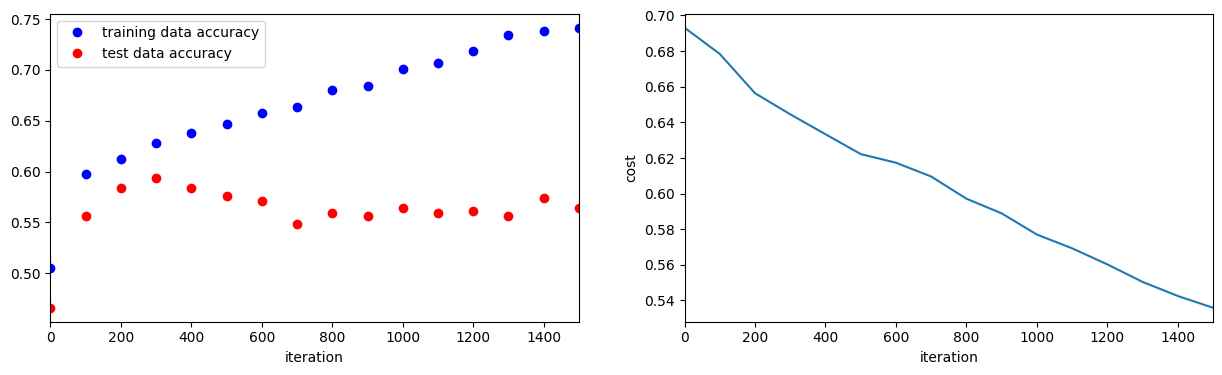

In [ ]:
if 0:#activate to run
    n_iter=1500
    print_cost_every=100
    parameters,accuracy_train,accuracy_test,costs = two_layer_model(train_x_flatten, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = n_iter, print_cost_every=print_cost_every)

    #plot the output
    fig,ax=plt.subplots(1,2,figsize=(15,4))
    x=np.arange(0,n_iter+print_cost_every,print_cost_every)
    ax[1].plot(x,costs)
    ax[1].set_ylabel('cost')
    ax[0].plot(x,np.squeeze(accuracy_traiWe see that first, both the training and test accuracies are getting better. However, when we keep on, we see the training accuracy incresing, but the test accuracy decay. We are overfitting the training data set, $\textit{i.e.}$ we create a NN that is really good on the training data, but that cannot generalize to other data. (pretty much after 100 images)n),'bo',label='training data accuracy')
    ax[0].plot(x,np.squeeze(accuracy_test),'ro',label='test data accuracy')
    ax[0].set_xlabel('iteration');ax[1].set_xlabel('iteration')
    ax[0].set_xlim(0,n_iter);ax[1].set_xlim(0,n_iter)
    ax[0].legend()

At first, both the training and test accuracies are getting better. However, the training accuracy increses, but the test accuracy decay. The training data set is overfitting.

The model is to well fitted to the training data which means its not generall enough and wont fit on anything else than the traning data. This can be improved by using less epochs when training the data.<br>
<br>
When i changed the image size to 15 I can see that the model isnt overfittet as fast as with the original image size 32 (see below) I guess that is because each datapoint will have less information when the image size is smaller and therefore the model isnt fit as "closely" to the training data an therefore also fits better to the test data.

Train accuracy after iteration 0: 0.506
Test accuracy after iteration 0: 0.47117794486215536
Train accuracy after iteration 100: 0.5545
Test accuracy after iteration 100: 0.531328320802005
Train accuracy after iteration 200: 0.591
Test accuracy after iteration 200: 0.568922305764411
Train accuracy after iteration 300: 0.599
Test accuracy after iteration 300: 0.5789473684210527
Train accuracy after iteration 400: 0.607
Test accuracy after iteration 400: 0.581453634085213
Train accuracy after iteration 500: 0.6175
Test accuracy after iteration 500: 0.5889724310776943
Train accuracy after iteration 600: 0.615
Test accuracy after iteration 600: 0.5964912280701754
Train accuracy after iteration 700: 0.6235
Test accuracy after iteration 700: 0.5914786967418546
Train accuracy after iteration 800: 0.629
Test accuracy after iteration 800: 0.5989974937343359
Train accuracy after iteration 900: 0.63
Test accuracy after iteration 900: 0.5914786967418546
Train accuracy after iteration 1000: 0.634
T

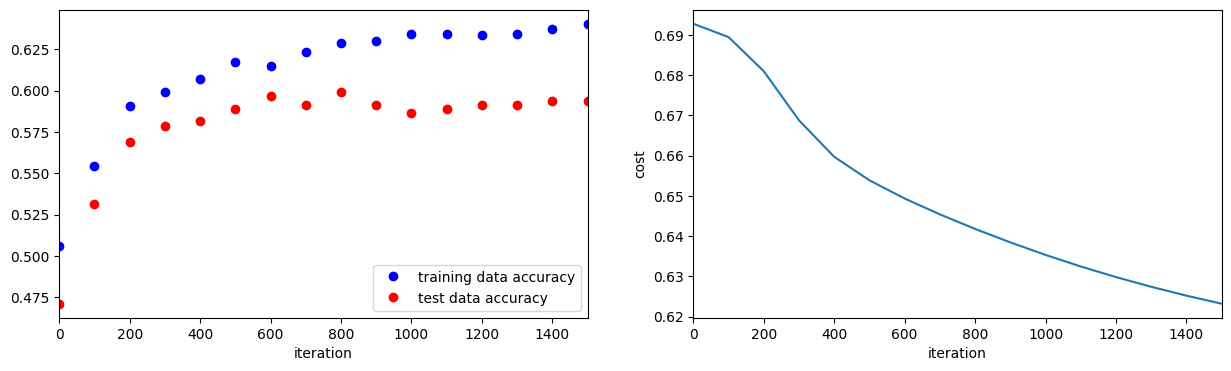

In [ ]:
# Rerun the code above
if 1:#activate to run
    n_iter=1500
    print_cost_every=100
    parameters,accuracy_train,accuracy_test,costs = two_layer_model(train_x_flatten, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = n_iter, print_cost_every=print_cost_every)

    #plot the output
    fig,ax=plt.subplots(1,2,figsize=(15,4))
    x=np.arange(0,n_iter+print_cost_every,print_cost_every)
    ax[1].plot(x,costs)
    ax[1].set_ylabel('cost')
    ax[0].plot(x,np.squeeze(accuracy_train),'bo',label='training data accuracy')
    ax[0].plot(x,np.squeeze(accuracy_test),'ro',label='test data accuracy')
    ax[0].set_xlabel('iteration');ax[1].set_xlabel('iteration')
    ax[0].set_xlim(0,n_iter);ax[1].set_xlim(0,n_iter)
    ax[0].legend()
